# Code-Capacity Performance Heat Map

This notebook studies **disordered memory BP** on standard code-capacity random `X` errors at fixed physical error rate `p = 0.05`.

Experiment convention:
- choose a CSS code from the `CODE_PATHS` dictionary
- sample i.i.d. random `X` errors with Bernoulli rate `p_random_error`
- compute syndrome with `Hz`
- decode with `Hz`
- evaluate logical success using `Lz`

The heat-map axes are the coefficient distribution parameters:
- `x` axis = coefficient distribution center
- `y` axis = coefficient distribution width

At each `(center, width)` point:
- the same pre-sampled random error set is reused for fairness
- multiple random coefficient realizations are sampled per error shot
- results are averaged across all random error shots and all coefficient draws

The coefficient distribution is uniform on:
`[center - width / 2, center + width / 2]`

So large widths can introduce negative coefficients automatically.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy import sparse

import relay_bp

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=160, suppress=True)

In [11]:
CODE_PATHS = {
    "hgp_625": Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
    "hgp_225": Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
    "surface5": Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
    "surface13": Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
    "B1": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
    "gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz"),
    "two_gross": Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\two_gross_HxHzLxLz.npz"),
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

p_random_error = 0.06
prior_error_rate = p_random_error
max_iter = 40
alpha = 1.0

center_values = np.linspace(0.0, 1.0, 11)
width_values = np.linspace(0.0, 2.0, 11)
random_draws_per_point = 100
n_error_samples = 100
base_seed = 0

show_progress = True
show_inner_case_progress = False

sample_limit = None  # set to an integer for a quick smoke run

assert np.all(width_values >= 0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."
assert n_error_samples > 0, "n_error_samples must be positive."

In [12]:
def load_css_code(path: Path) -> dict[str, np.ndarray]:
    data = np.load(path, allow_pickle=True)
    return {key: np.asarray(data[key], dtype=np.uint8) % 2 for key in ["Hx", "Hz", "Lx", "Lz"]}


def sample_random_x_errors(hz: np.ndarray, n_samples: int, p: float, base_seed: int) -> list[dict[str, object]]:
    n_bits = hz.shape[1]
    cases = []
    for sample_idx in range(int(n_samples)):
        rng = np.random.default_rng(int(base_seed) + sample_idx)
        error = (rng.random(n_bits) < float(p)).astype(np.uint8)
        syndrome = np.asarray((hz @ error) % 2, dtype=np.uint8).reshape(-1)
        cases.append({
            "sample_idx": int(sample_idx),
            "error": error,
            "error_weight": int(error.sum()),
            "syndrome": syndrome,
            "syndrome_weight": int(syndrome.sum()),
        })
    if sample_limit is not None:
        cases = cases[: int(sample_limit)]
    return cases


def sample_statistics(cases: list[dict[str, object]]) -> pd.DataFrame:
    error_weights = np.asarray([case["error_weight"] for case in cases], dtype=int)
    syndrome_weights = np.asarray([case["syndrome_weight"] for case in cases], dtype=int)
    return pd.DataFrame([
        {
            "code": selected_code,
            "n_samples": int(len(cases)),
            "p_random_error": float(p_random_error),
            "mean_error_weight": float(error_weights.mean()) if len(error_weights) else np.nan,
            "mean_syndrome_weight": float(syndrome_weights.mean()) if len(syndrome_weights) else np.nan,
            "zero_error_rate": float((error_weights == 0).mean()) if len(error_weights) else np.nan,
            "zero_syndrome_rate": float((syndrome_weights == 0).mean()) if len(syndrome_weights) else np.nan,
            "max_error_weight": int(error_weights.max()) if len(error_weights) else -1,
            "max_syndrome_weight": int(syndrome_weights.max()) if len(syndrome_weights) else -1,
        }
    ])


def sample_manifest(cases: list[dict[str, object]]) -> pd.DataFrame:
    rows = []
    for case in cases:
        rows.append({
            "sample_idx": case["sample_idx"],
            "error_weight": case["error_weight"],
            "syndrome_weight": case["syndrome_weight"],
            "error_support": np.flatnonzero(case["error"]).astype(int).tolist(),
        })
    return pd.DataFrame(rows)


def build_memory_strengths(n_bits: int, center: float, width: float, coeff_seed: int) -> np.ndarray:
    if width < 0:
        raise ValueError("width must be non-negative")

    if float(width) == 0.0:
        return np.full(n_bits, float(center), dtype=np.float64)

    low = float(center) - float(width) / 2.0
    high = float(center) + float(width) / 2.0
    rng = np.random.default_rng(int(coeff_seed))
    return rng.uniform(low, high, size=n_bits).astype(np.float64)


def make_tracer(check_matrix, error_priors: np.ndarray):
    return relay_bp.MinSumBPDecoderTraceF64(
        check_matrix,
        error_priors=error_priors,
        max_iter=max_iter,
        alpha=alpha,
        gamma0=0.0,
    )


def decode_case_with_tracer(tracer, syndrome: np.ndarray, memory_strengths: np.ndarray):
    tracer.reset()
    tracer.set_memory_strengths(memory_strengths)
    result = tracer.snapshot(syndrome)
    while tracer.current_iteration < max_iter and not result.success:
        result = tracer.run_iteration(syndrome)
    return result


def evaluate_parameter_heatmaps(cases: list[dict[str, object]], check_matrix, lz: np.ndarray):
    error_priors = np.full(check_matrix.shape[1], prior_error_rate, dtype=np.float64)
    tracer = make_tracer(check_matrix, error_priors)

    shape = (len(width_values), len(center_values))
    logical_success_rate = np.zeros(shape, dtype=np.float64)
    convergence_rate = np.zeros(shape, dtype=np.float64)
    exact_recovery_rate = np.zeros(shape, dtype=np.float64)
    mean_iterations = np.zeros(shape, dtype=np.float64)
    max_iterations_rate = np.zeros(shape, dtype=np.float64)
    trial_count = np.zeros(shape, dtype=np.int64)

    if not cases:
        raise ValueError("No random error samples were generated for the current settings.")

    parameter_points = [
        (width_idx, float(width), center_idx, float(center))
        for width_idx, width in enumerate(width_values)
        for center_idx, center in enumerate(center_values)
    ]
    parameter_points_iter = tqdm(
        parameter_points,
        total=len(parameter_points),
        desc="heatmap grid",
        disable=not show_progress,
    )

    for width_idx, width, center_idx, center in parameter_points_iter:
        logical_success_sum = 0.0
        convergence_sum = 0.0
        exact_recovery_sum = 0.0
        iteration_sum = 0.0
        max_iter_sum = 0.0
        n_trials = 0

        cases_iter = tqdm(
            cases,
            total=len(cases),
            desc=f"w={width:.3f}, c={center:.3f}",
            leave=False,
            disable=(not show_progress) or (not show_inner_case_progress),
        )

        for case in cases_iter:
            for draw_idx in range(random_draws_per_point):
                coeff_seed = (
                    int(base_seed)
                    + 1_000_003 * int(case["sample_idx"])
                    + 10_007 * int(width_idx)
                    + 1_009 * int(center_idx)
                    + int(draw_idx)
                )
                memory_strengths = build_memory_strengths(
                    check_matrix.shape[1],
                    center=float(center),
                    width=float(width),
                    coeff_seed=coeff_seed,
                )
                result = decode_case_with_tracer(tracer, case["syndrome"], memory_strengths)
                decoding = np.asarray(result.decoding, dtype=np.uint8)
                residual = np.bitwise_xor(decoding, case["error"])
                logical_signature = np.asarray((lz @ residual) % 2, dtype=np.uint8).reshape(-1)
                logical_ok = bool(np.all(logical_signature == 0))
                exact_ok = bool(np.array_equal(decoding, case["error"]))

                logical_success_sum += float(logical_ok)
                convergence_sum += float(bool(result.success))
                exact_recovery_sum += float(exact_ok)
                iteration_sum += float(result.iterations)
                max_iter_sum += float(int(result.iterations) >= int(max_iter))
                n_trials += 1

        logical_success_rate[width_idx, center_idx] = logical_success_sum / n_trials
        convergence_rate[width_idx, center_idx] = convergence_sum / n_trials
        exact_recovery_rate[width_idx, center_idx] = exact_recovery_sum / n_trials
        mean_iterations[width_idx, center_idx] = iteration_sum / n_trials
        max_iterations_rate[width_idx, center_idx] = max_iter_sum / n_trials
        trial_count[width_idx, center_idx] = n_trials

        parameter_points_iter.set_postfix(
            width=f"{width:.3f}",
            center=f"{center:.3f}",
            logical=f"{logical_success_rate[width_idx, center_idx]:.3f}",
            conv=f"{convergence_rate[width_idx, center_idx]:.3f}",
        )

    return {
        "logical_success_rate": logical_success_rate,
        "convergence_rate": convergence_rate,
        "exact_recovery_rate": exact_recovery_rate,
        "mean_iterations": mean_iterations,
        "max_iterations_rate": max_iterations_rate,
        "trial_count": trial_count,
    }


def grid_table(artifact: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for width_idx, width in enumerate(width_values):
        for center_idx, center in enumerate(center_values):
            rows.append({
                "center": float(center),
                "width": float(width),
                "interval_low": float(center - width / 2.0),
                "interval_high": float(center + width / 2.0),
                "logical_success_rate": float(artifact["logical_success_rate"][width_idx, center_idx]),
                "convergence_rate": float(artifact["convergence_rate"][width_idx, center_idx]),
                "exact_recovery_rate": float(artifact["exact_recovery_rate"][width_idx, center_idx]),
                "mean_iterations": float(artifact["mean_iterations"][width_idx, center_idx]),
                "max_iterations_rate": float(artifact["max_iterations_rate"][width_idx, center_idx]),
                "trial_count": int(artifact["trial_count"][width_idx, center_idx]),
            })
    return pd.DataFrame(rows)


def best_points_table(grid_df: pd.DataFrame) -> pd.DataFrame:
    best_logical = grid_df.sort_values(["logical_success_rate", "convergence_rate", "mean_iterations"], ascending=[False, False, True]).head(5).copy()
    best_logical.insert(0, "ranking", ["best logical"] * len(best_logical))

    best_convergence = grid_df.sort_values(["convergence_rate", "logical_success_rate", "mean_iterations"], ascending=[False, False, True]).head(5).copy()
    best_convergence.insert(0, "ranking", ["best convergence"] * len(best_convergence))

    best_speed = grid_df.sort_values(["mean_iterations", "logical_success_rate", "convergence_rate"], ascending=[True, False, False]).head(5).copy()
    best_speed.insert(0, "ranking", ["fastest"] * len(best_speed))

    return pd.concat([best_logical, best_convergence, best_speed], ignore_index=True)


def plot_parameter_heatmaps(artifact: dict[str, np.ndarray]):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), squeeze=False)
    axes = axes.ravel()

    x_min, x_max = float(center_values[0]), float(center_values[-1])
    y_min, y_max = float(width_values[0]), float(width_values[-1])
    extent = [x_min, x_max, y_min, y_max]

    im0 = axes[0].imshow(artifact["logical_success_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[0].set_title("logical success rate")
    axes[0].set_xlabel("coefficient center")
    axes[0].set_ylabel("coefficient width")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(artifact["convergence_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[1].set_title("convergence rate")
    axes[1].set_xlabel("coefficient center")
    axes[1].set_ylabel("coefficient width")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(artifact["exact_recovery_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[2].set_title("exact recovery rate")
    axes[2].set_xlabel("coefficient center")
    axes[2].set_ylabel("coefficient width")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(artifact["mean_iterations"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="magma", vmin=0.0, vmax=float(max_iter))
    axes[3].set_title("mean iterations")
    axes[3].set_xlabel("coefficient center")
    axes[3].set_ylabel("coefficient width")
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    fig.suptitle(
        f"Disordered Mem-BP | random X errors | code = {selected_code} | p = {p_random_error} | draws/point = {random_draws_per_point} | shots = {len(random_error_cases)}",
        fontsize=13,
        y=1.02,
    )
    fig.tight_layout()
    return fig


code_data = load_css_code(npz_path)
hz_check_matrix = sparse.csc_matrix(code_data["Hz"].astype(np.uint8))
lz_matrix = code_data["Lz"].astype(np.uint8)
random_error_cases = sample_random_x_errors(code_data["Hz"], n_error_samples, p_random_error, base_seed)
setup_df = pd.DataFrame([
    {
        "code": selected_code,
        "npz_path": str(npz_path),
        "Hx_shape": code_data["Hx"].shape,
        "Hz_shape": code_data["Hz"].shape,
        "Lx_shape": code_data["Lx"].shape,
        "Lz_shape": code_data["Lz"].shape,
        "p_random_error": p_random_error,
        "prior_error_rate": prior_error_rate,
        "max_iter": max_iter,
        "random_draws_per_point": random_draws_per_point,
        "n_center_values": len(center_values),
        "n_width_values": len(width_values),
        "n_error_samples": len(random_error_cases),
        "sample_limit": sample_limit,
        "show_progress": show_progress,
        "show_inner_case_progress": show_inner_case_progress,
    }
])

display(setup_df)

,code,npz_path,Hx_shape,Hz_shape,Lx_shape,Lz_shape,p_random_error,prior_error_rate,max_iter,random_draws_per_point,n_center_values,n_width_values,n_error_samples,sample_limit,show_progress,show_inner_case_progress
0,gross,C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\gross_HxHzLxLz.npz,"(72, 144)","(72, 144)","(12, 144)","(12, 144)",0.06,0.06,40,100,11,11,100,None,True,False


## Random Error Sample Summary

The next cells report summary statistics of the pre-sampled random `X`-error set and show the first part of the sampled error manifest.

In [13]:
sample_stats_df = sample_statistics(random_error_cases)
manifest_df = sample_manifest(random_error_cases)
display(sample_stats_df)
display(manifest_df.head(20))

,code,n_samples,p_random_error,mean_error_weight,mean_syndrome_weight,zero_error_rate,zero_syndrome_rate,max_error_weight,max_syndrome_weight
0,gross,100,0.06,8.55,18.81,0.0,0.0,16,32


,sample_idx,error_weight,syndrome_weight,error_support
0,0,11,21,"[2, 3, 11, 13, 20, 53, 59, 92, 108, 111, 113]"
1,1,5,11,"[9, 36, 61, 75, 93]"
2,2,13,19,"[7, 49, 64, 80, 84, 86, 89, 93, 97, 106, 117, 133, 141]"
3,3,5,13,"[20, 28, 74, 89, 104]"
4,4,2,6,"[51, 116]"
5,5,12,24,"[4, 7, 8, 29, 31, 48, 88, 111, 112, 129, 130, 134]"
6,6,7,15,"[10, 12, 16, 46, 50, 83, 127]"
7,7,11,19,"[6, 23, 24, 32, 37, 52, 90, 96, 98, 114, 120]"
8,8,6,16,"[24, 39, 104, 124, 127, 136]"
9,9,8,18,"[8, 12, 58, 67, 69, 88, 102, 135]"


## Coefficient Heat Maps

This cell runs the disordered memory BP decoder across all pre-sampled random error shots.

For each `(center, width)` point:
- a fresh random coefficient realization is sampled `random_draws_per_point` times per shot
- the coefficient interval is `[center - width / 2, center + width / 2]`
- results are averaged across all random error shots and all random draws

heatmap grid:   0%|          | 0/121 [00:00<?, ?it/s]

heatmap grid: 100%|██████████| 121/121 [02:42<00:00,  1.34s/it, center=1.000, conv=0.996, logical=0.500, width=2.000]


,ranking,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,max_iterations_rate,trial_count
0,best logical,0.1,0.6,-0.2,0.4,0.9188,0.9820,0.8491,0.8522,0.0180,10000
1,best logical,0.2,0.2,0.1,0.3,0.9165,0.9939,0.8195,0.3575,0.0063,10000
2,best logical,0.1,0.4,-0.1,0.3,0.9097,0.9486,0.8271,2.1721,0.0515,10000
3,best logical,0.2,0.4,0.0,0.4,0.9068,0.9927,0.8170,0.4055,0.0074,10000
4,best logical,0.1,0.8,-0.3,0.5,0.9014,0.9824,0.8124,0.8396,0.0180,10000
5,best convergence,0.7,1.0,0.2,1.2,0.6900,0.9999,0.5300,0.1045,0.0001,10000
6,best convergence,0.4,0.4,0.2,0.6,0.8199,0.9998,0.6899,0.1092,0.0002,10000
7,best convergence,0.5,0.8,0.1,0.9,0.7598,0.9998,0.6400,0.1069,0.0002,10000
8,best convergence,0.6,0.6,0.3,0.9,0.7200,0.9998,0.5900,0.1093,0.0002,10000
9,best convergence,0.5,0.2,0.4,0.6,0.7600,0.9997,0.6300,0.1112,0.0003,10000


,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,max_iterations_rate,trial_count
34,0.1,0.6,-0.2,0.4,0.9188,0.9820,0.8491,0.8522,0.0180,10000
13,0.2,0.2,0.1,0.3,0.9165,0.9939,0.8195,0.3575,0.0063,10000
23,0.1,0.4,-0.1,0.3,0.9097,0.9486,0.8271,2.1721,0.0515,10000
24,0.2,0.4,0.0,0.4,0.9068,0.9927,0.8170,0.4055,0.0074,10000
45,0.1,0.8,-0.3,0.5,0.9014,0.9824,0.8124,0.8396,0.0180,10000
35,0.2,0.6,-0.1,0.5,0.8992,0.9955,0.7892,0.2894,0.0045,10000
12,0.1,0.2,0.0,0.2,0.8989,0.9489,0.8388,2.1610,0.0511,10000
56,0.1,1.0,-0.4,0.6,0.8956,0.9717,0.7874,1.2827,0.0283,10000
57,0.2,1.0,-0.3,0.7,0.8950,0.9932,0.7857,0.4108,0.0070,10000
67,0.1,1.2,-0.5,0.7,0.8824,0.9485,0.7940,2.2257,0.0516,10000


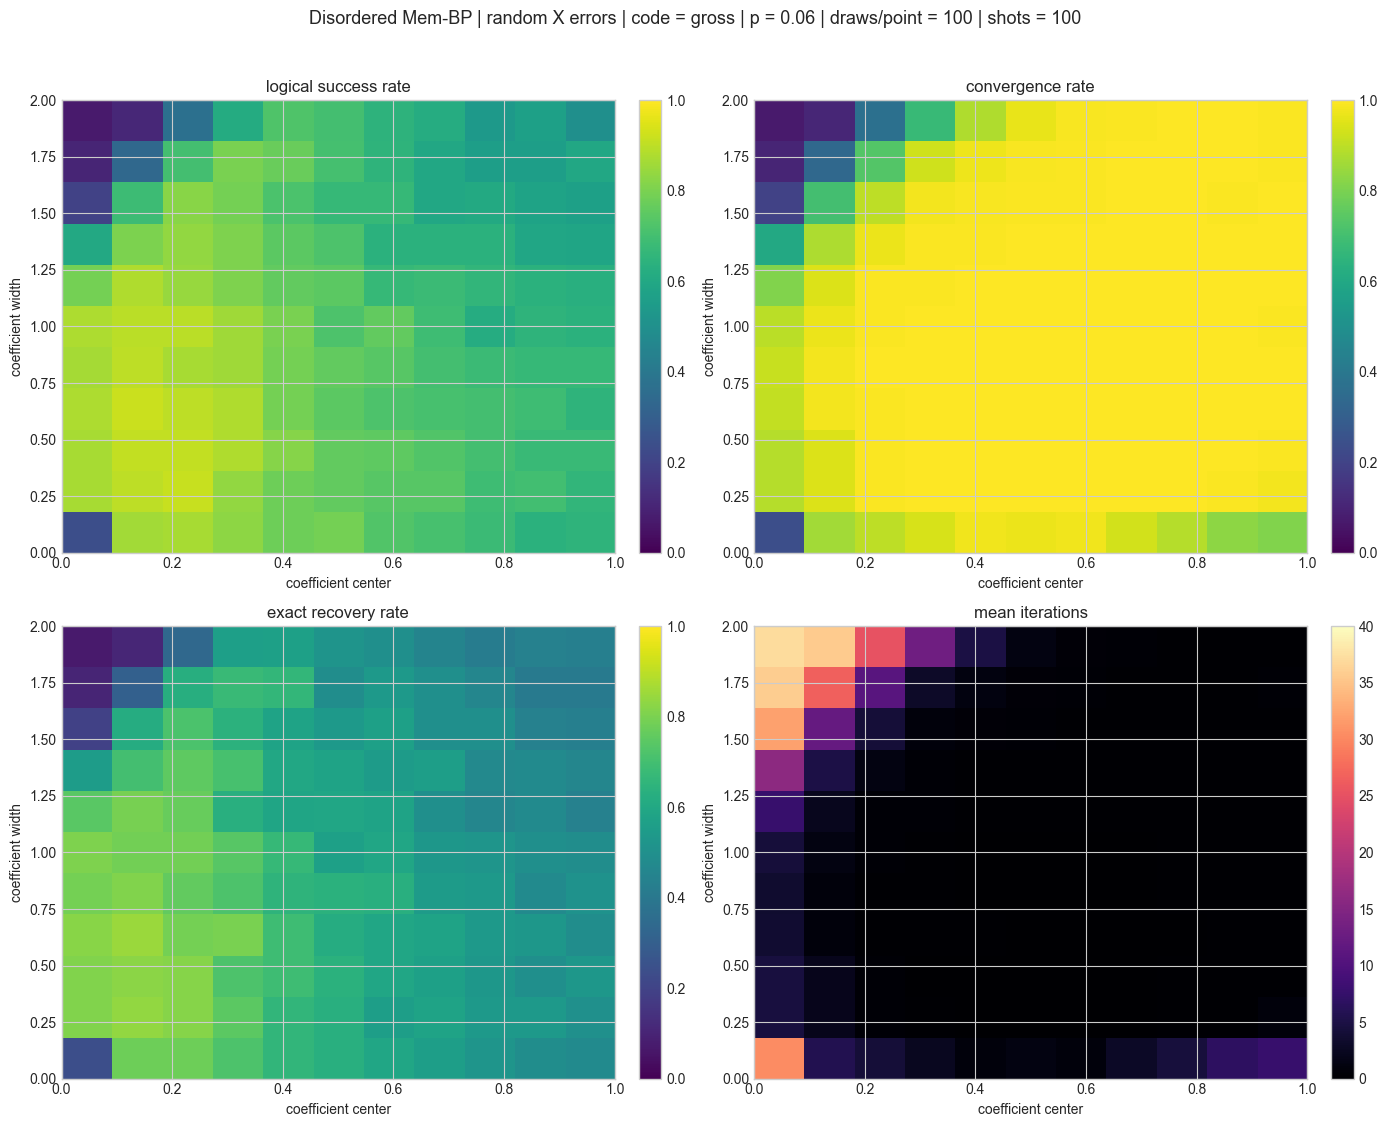

In [14]:
artifact = evaluate_parameter_heatmaps(random_error_cases, hz_check_matrix, lz_matrix)
grid_df = grid_table(artifact)
best_df = best_points_table(grid_df)

display(best_df)
display(grid_df.sort_values(["logical_success_rate", "convergence_rate", "mean_iterations"], ascending=[False, False, True]).head(20))
plot_parameter_heatmaps(artifact);
plt.show()

In [ ]:
p_random_error = 0.03
prior_error_rate = p_random_error
max_iter = 40
alpha = 1.0

center_values = np.linspace(0.2, 0.8, 3)
width_values = np.linspace(0.2, 0.8, 5)
random_draws_per_point = 1000
n_error_samples = 1000
base_seed = 0


random_error_cases = sample_random_x_errors(code_data["Hz"], n_error_samples, p_random_error, base_seed)


artifact = evaluate_parameter_heatmaps(random_error_cases, hz_check_matrix, lz_matrix)
heatmap_df = grid_table(artifact)

grid_df = grid_table(artifact)
best_df = best_points_table(grid_df)

display(best_df)

display(heatmap_df.head(16))
fig = plot_parameter_heatmaps(artifact)

NameError: name 'np' is not defined

heatmap grid: 100%|██████████| 3/3 [05:10<00:00, 103.56s/it, center=0.400, conv=1.000, logical=0.994, width=0.400]


,ranking,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,max_iterations_rate,trial_count
0,best logical,0.2,0.4,0.0,0.4,0.996996,0.999996,0.977996,0.003564,0.000004,1000000
1,best logical,0.3,0.4,0.1,0.5,0.995998,0.999997,0.977998,0.003284,0.000003,1000000
2,best logical,0.4,0.4,0.2,0.6,0.993997,0.999997,0.972997,0.003229,0.000003,1000000
3,best convergence,0.3,0.4,0.1,0.5,0.995998,0.999997,0.977998,0.003284,0.000003,1000000
4,best convergence,0.4,0.4,0.2,0.6,0.993997,0.999997,0.972997,0.003229,0.000003,1000000
5,best convergence,0.2,0.4,0.0,0.4,0.996996,0.999996,0.977996,0.003564,0.000004,1000000
6,fastest,0.4,0.4,0.2,0.6,0.993997,0.999997,0.972997,0.003229,0.000003,1000000
7,fastest,0.3,0.4,0.1,0.5,0.995998,0.999997,0.977998,0.003284,0.000003,1000000
8,fastest,0.2,0.4,0.0,0.4,0.996996,0.999996,0.977996,0.003564,0.000004,1000000


,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,max_iterations_rate,trial_count
0,0.2,0.4,0.0,0.4,0.996996,0.999996,0.977996,0.003564,0.000004,1000000
1,0.3,0.4,0.1,0.5,0.995998,0.999997,0.977998,0.003284,0.000003,1000000
2,0.4,0.4,0.2,0.6,0.993997,0.999997,0.972997,0.003229,0.000003,1000000


C:\Users\User\AppData\Local\Temp\ipykernel_20056\2264825531.py:223: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im0 = axes[0].imshow(artifact["logical_success_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
C:\Users\User\AppData\Local\Temp\ipykernel_20056\2264825531.py:229: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im1 = axes[1].imshow(artifact["convergence_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
C:\Users\User\AppData\Local\Temp\ipykernel_20056\2264825531.py:235: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im2 = axes[2].imshow(artifact["exact_recovery_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest

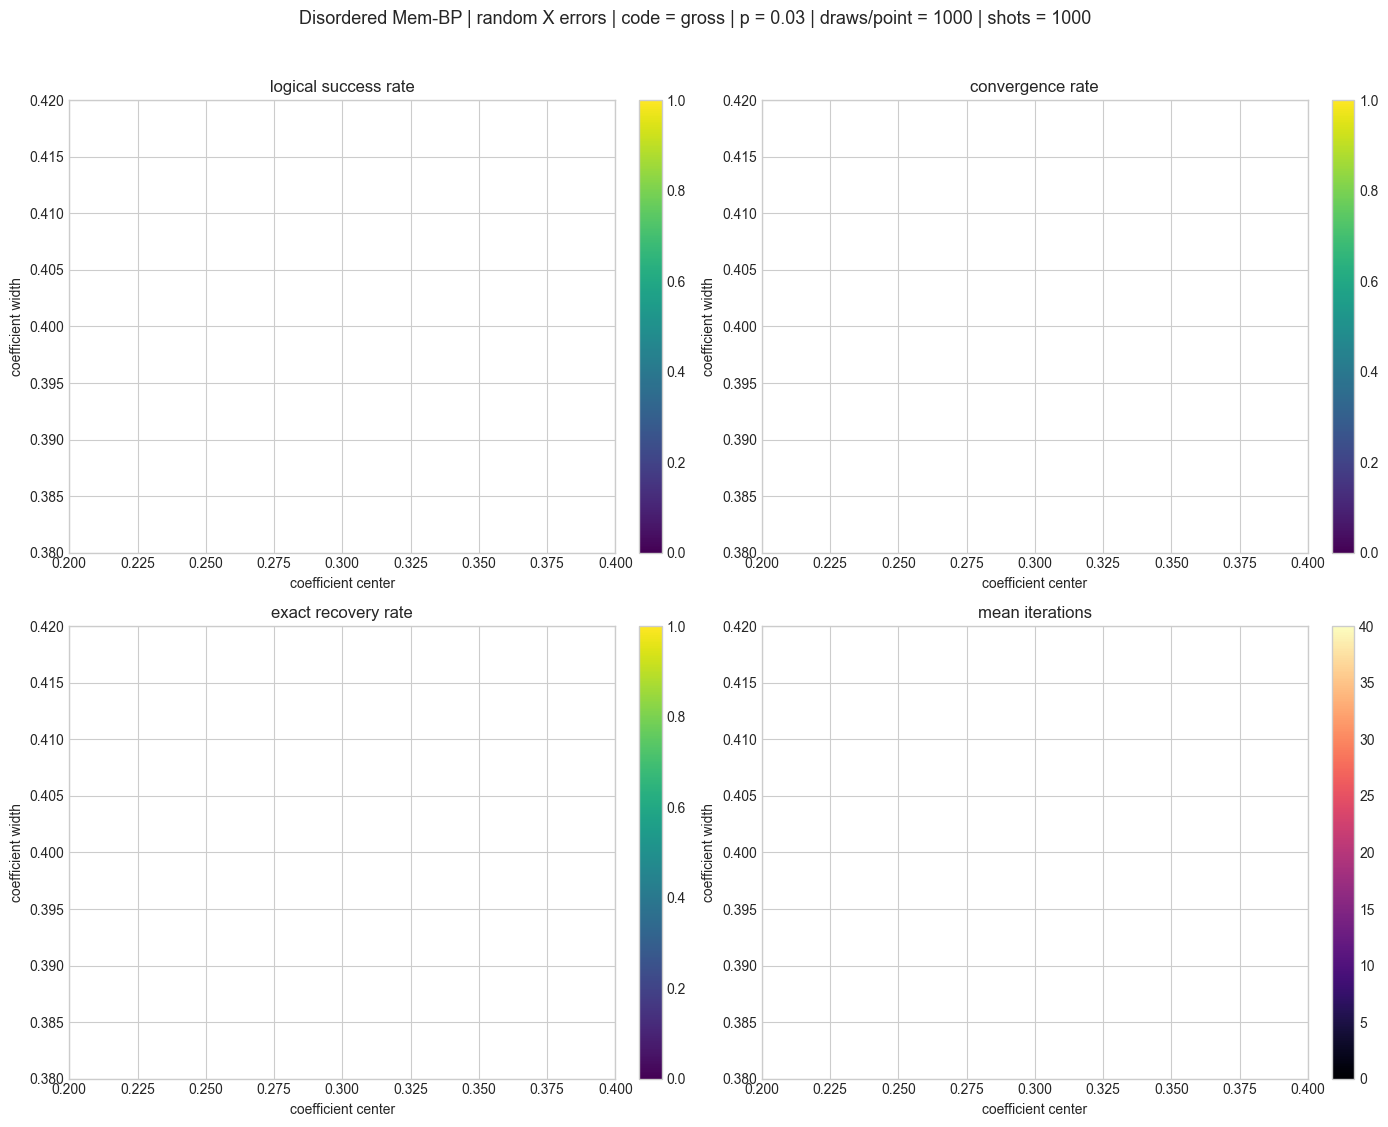

In [6]:
p_random_error = 0.03
prior_error_rate = p_random_error
max_iter = 40
alpha = 1.0

center_values = np.linspace(0.2, 0.4, 3)
width_values = np.linspace(0.4, 0.4, 1)
random_draws_per_point = 1000
n_error_samples = 1000
base_seed = 0


random_error_cases = sample_random_x_errors(code_data["Hz"], n_error_samples, p_random_error, base_seed)


artifact = evaluate_parameter_heatmaps(random_error_cases, hz_check_matrix, lz_matrix)
heatmap_df = grid_table(artifact)

grid_df = grid_table(artifact)
best_df = best_points_table(grid_df)

display(best_df)

display(heatmap_df.head(16))
fig = plot_parameter_heatmaps(artifact)